# Victorian Poster OCR — Qwen2.5-VL-3B-Instruct (8-bit)

Extract **act names** and **performer information** from 1800s theatre posters using Qwen2.5-VL-3B-Instruct with 8-bit quantization (~5 GB VRAM).

**Input**: `cleaned_binarized_posters.zip` — a zip archive of pre-cleaned poster images.

**Output**: `results.json` — structured JSON with venue, date, acts, performers, and descriptions.

---

# Install Libraries

In [ ]:
!pip install -q torch torchvision transformers accelerate qwen-vl-utils bitsandbytes
!pip install -q opencv-python-headless Pillow

In [ ]:
import json
import os
import re
import time
import zipfile
from pathlib import Path

import torch
from PIL import Image
from IPython.display import display, JSON, clear_output
from transformers import (
    Qwen2_5_VLForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig,
)
from qwen_vl_utils import process_vision_info

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".tiff", ".tif", ".bmp", ".webp"}

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 34.6 MB/s eta 0:00:00


# Configuration

In [ ]:
# Path directories
ZIP_PATH = "cleaned_binarized_posters.zip"
EXTRACT_DIR = "./extracted_posters"
OUTPUT_PATH = "results.json"

# Model settings
MODEL_ID = "Qwen/Qwen2.5-VL-3B-Instruct"
DEVICE = "auto"
MAX_NEW_TOKENS = 2048
TEMPERATURE = 0.1
MAX_PIXELS = 1003520
MIN_PIXELS = 3136

# Extract Zip Images

In [ ]:
def extract_zip(zip_path: str, extract_dir: str) -> list:
    """Extract zip and return sorted list of image paths"""
    os.makedirs(extract_dir, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as zf:
        members = [
            m for m in zf.namelist()
            if not m.startswith("__MACOSX")
            and not os.path.basename(m).startswith(".")
            and not m.endswith("/")
        ]
        zf.extractall(extract_dir, members)

    image_paths = []
    for root, dirs, files in os.walk(extract_dir):
        for fname in files:
            if Path(fname).suffix.lower() in IMAGE_EXTENSIONS:
                image_paths.append(os.path.join(root, fname))

    image_paths.sort()
    return image_paths


# Start extraction
image_paths = extract_zip(ZIP_PATH, EXTRACT_DIR)
print(f"Extracted {len(image_paths)} images from {ZIP_PATH}")
print(f"\nFirst 10 files:")
for p in image_paths[:10]:
    print(f"  {os.path.basename(p)}")
if len(image_paths) > 10:
    print(f"  ... and {len(image_paths) - 10} more")

Extracted 30 images from cleaned_binarized_posters.zip

First 10 files:
  NFA178R12-103_binarized.png
  NFA178R12-104_binarized.png
  NFA178R12-10_binarized.png
  NFA178R12-16_binarized.png
  NFA178R12-17_binarized.png
  NFA178R12-18_binarized.png
  NFA178R12-204_binarized.png
  NFA178R12-205_binarized.png
  NFA178R12-207_binarized.png
  NFA178R12-208_binarized.png
  ... and 20 more


# Preview Images

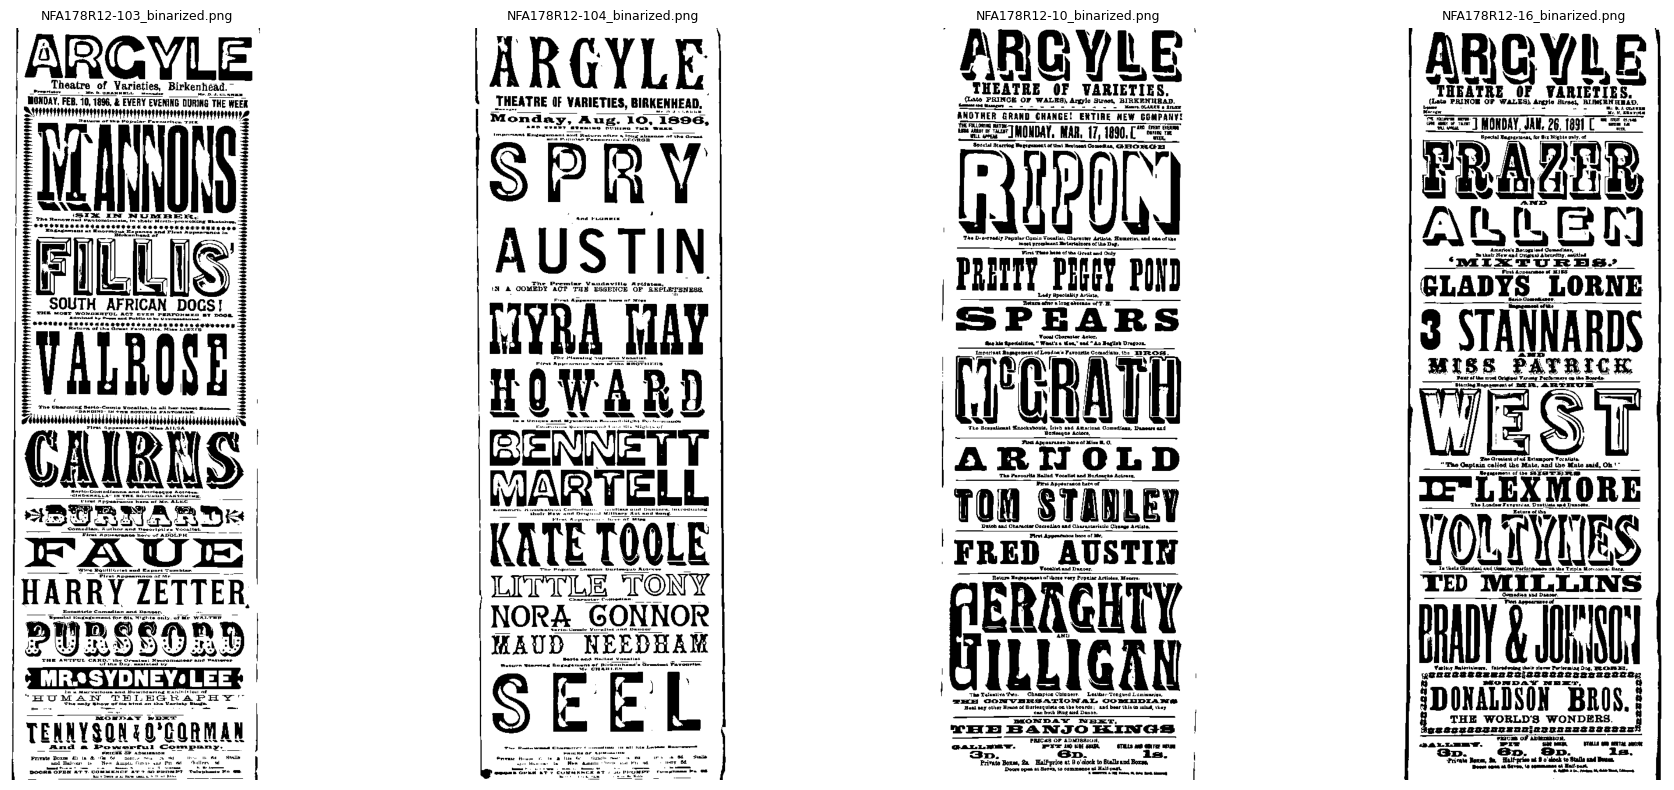

Image sizes: [(436, 1292), (455, 1292), (445, 1292), (451, 1292)]


In [ ]:
import matplotlib.pyplot as plt

preview_count = min(4, len(image_paths))
fig, axes = plt.subplots(1, preview_count, figsize=(5 * preview_count, 8))
if preview_count == 1:
    axes = [axes]

for ax, img_path in zip(axes, image_paths[:preview_count]):
    img = Image.open(img_path)
    ax.imshow(img, cmap="gray" if img.mode == "L" else None)
    ax.set_title(os.path.basename(img_path)[:30], fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()
print(f"Image sizes: {[Image.open(p).size for p in image_paths[:preview_count]]}")

# Load Model in 8-bit Quantization

In [ ]:
print(f"Loading {MODEL_ID} in 8-bit")
start = time.time()

# 8-bit quantization config
quantization_config = BitsAndBytesConfig(load_in_8bit=True)

# Load model
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map=DEVICE,
    quantization_config=quantization_config,
    attn_implementation="sdpa",
)

processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    min_pixels=MIN_PIXELS,
    max_pixels=MAX_PIXELS,
)

elapsed = time.time() - start
print(f"Model loaded in {elapsed:.1f}s")

Loading Qwen/Qwen2.5-VL-3B-Instruct with 8-bit quantization...


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Model loaded in 137.5s
GPU memory used: 4.11 GB


# Prompts & Inference Functions

In [ ]:
SYSTEM_PROMPT = """
You are a specialist in reading and transcribing text from Victorian-era theatre and variety show posters from the 1800s. These posters use decorative typefaces, mixed font sizes, and archaic language.

Your task is to extract structured information from poster images.
For each poster, identify:

1. **Venue**: The name and location of the theatre/venue
2. **Date**: Any dates mentioned on the poster
3. **Acts**: Each act or performance listed, with:
   - **act_name**: The name of the act or show (e.g. "Silvani Troupe", "Back From Kansas")
   - **performers**: Individual performer names associated with that act
   - **description**: Any description of the act (e.g. "Comedian and Vocalist")
   - **billing_notes**: Special billing text (e.g. "First Appearance in Birkenhead")

Respond ONLY with valid JSON in this exact format:
{
  "venue": {"name": "...", "location": "..."},
  "date": "...",
  "acts": [
    {
      "act_name": "...",
      "performers": ["..."],
      "description": "...",
      "billing_notes": "..."
    }
  ],
  "ticket_prices": "...",
  "additional_info": "..."
}

Be thorough — even small text between large headlines often contains performer names and descriptions. If text is illegible, use [illegible]. Do not guess or hallucinate text that you cannot read.
"""


def extract_text_from_image(image_path: str) -> str:
    """
    Run Qwen2.5-VL inference on a single poster image.
    Returns the raw model output string.
    """
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": f"file://{os.path.abspath(image_path)}",
                },
                {
                    "type": "text",
                    "text": "Extract all acts and performers from this Victorian theatre poster.",
                },
            ],
        },
    ]

    # Apply chat template
    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

    # Process vision info
    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    ).to(model.device)

    # Generate
    with torch.inference_mode():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            temperature=TEMPERATURE,
            top_p=0.9,
            do_sample=TEMPERATURE > 0,
        )

    generated_ids = output_ids[:, inputs.input_ids.shape[1]:]
    output_text = processor.batch_decode(
        generated_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )[0]
    return output_text


def parse_json_response(text: str) -> dict:
    """
    Extract JSON from model output, handling markdown fences
    and minor formatting issues.
    """
    json_match = re.search(r"```(?:json)?\s*\n?(.*?)\n?```", text, re.DOTALL)
    if json_match:
        text = json_match.group(1)

    first_brace = text.find("{")
    last_brace = text.rfind("}")
    if first_brace != -1 and last_brace != -1:
        text = text[first_brace : last_brace + 1]

    try:
        return json.loads(text)
    except json.JSONDecodeError as e:
        return {"raw_text": text, "parse_error": str(e)}


print("Inference functions defined.")

Inference functions defined.


# Run Batch Extraction

In [ ]:
results = []
total = len(image_paths)
errors = 0
batch_start = time.time()

for i, img_path in enumerate(image_paths, 1):
    fname = os.path.basename(img_path)
    print(f"[{i}/{total}] {fname} ... ", end="", flush=True)
    img_start = time.time()

    try:
        raw_output = extract_text_from_image(img_path)
        result = parse_json_response(raw_output)
        result["source_image"] = img_path

        # Quick summary and progress report
        if "acts" in result:
            n_acts = len(result["acts"])
            n_perf = sum(len(a.get("performers", [])) for a in result["acts"])
            elapsed = time.time() - img_start
            print(f"{n_acts} acts, {n_perf} performers ({elapsed:.1f}s)")
        elif "parse_error" in result:
            print(f"JSON parse failed ({result['parse_error'][:60]})")
        else:
            print(f"done ({time.time() - img_start:.1f}s)")

        results.append(result)

    except Exception as e:
        errors += 1
        print(f"ERROR: {e}")
        results.append({"source_image": img_path, "error": str(e)})

    # Free GPU cache periodically
    if i % 10 == 0 and torch.cuda.is_available():
        torch.cuda.empty_cache()

batch_elapsed = time.time() - batch_start
print(f"\n{'='*60}")
print(f"Batch complete: {total - errors}/{total} succeeded in {batch_elapsed:.1f}s")
print(f"Average: {batch_elapsed / total:.1f}s per poster")
if errors:
    print(f"Errors: {errors}")

[1/30] NFA178R12-103_binarized.png ... 

/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 duri

5 acts, 5 performers (194.2s)
[2/30] NFA178R12-104_binarized.png ... 

/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 duri

7 acts, 8 performers (216.5s)
[3/30] NFA178R12-10_binarized.png ... 

...

8 acts, 8 performers (227.9s)
[29/30] NFA178R12-43_binarized.png ... 

/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 duri

1 acts, 1 performers (77.7s)
[30/30] NFA178R12-9_binarized.png ... 

/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 duri

3 acts, 8 performers (149.8s)

Batch complete: 30/30 succeeded in 4709.2s
Average: 157.0s per poster


# Save Results as json

In [ ]:
with open(OUTPUT_PATH, "w") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print(f"Results saved to: {OUTPUT_PATH}")
print(f"File size: {os.path.getsize(OUTPUT_PATH) / 1024:.1f} KB")

Results saved to: results.json
File size: 44.8 KB


# See Results

In [ ]:
# Summary table
print(f"{'Poster':<40} {'Acts':>5} {'Performers':>11} {'Status':>8}")
print("-" * 70)

total_acts = 0
total_performers = 0

for r in results:
    fname = os.path.basename(r.get("source_image", "?"))[:38]
    if "error" in r:
        print(f"{fname:<40} {'—':>5} {'—':>11} {'ERROR':>8}")
    elif "acts" in r:
        n_acts = len(r["acts"])
        n_perf = sum(len(a.get("performers", [])) for a in r["acts"])
        total_acts += n_acts
        total_performers += n_perf
        print(f"{fname:<40} {n_acts:>5} {n_perf:>11} {'OK':>8}")
    else:
        print(f"{fname:<40} {'?':>5} {'?':>11} {'PARTIAL':>8}")

print("-" * 70)
print(f"{'TOTAL':<40} {total_acts:>5} {total_performers:>11}")

Poster                                    Acts  Performers   Status
----------------------------------------------------------------------
NFA178R12-103_binarized.png                  5           5       OK
NFA178R12-104_binarized.png                  7           8       OK
NFA178R12-10_binarized.png                   4           4       OK
NFA178R12-16_binarized.png                   8           8       OK
NFA178R12-17_binarized.png                   2           7       OK
NFA178R12-18_binarized.png                   5           5       OK
NFA178R12-204_binarized.png                  3           5       OK
NFA178R12-205_binarized.png                  3           3       OK
NFA178R12-207_binarized.png                  6          10       OK
NFA178R12-208_binarized.png                  5           8       OK
NFA178R12-209_binarized.png                  7           2       OK
NFA178R12-211_binarized.png                  5           6       OK
NFA178R12-215_binarized.png                  

In [ ]:
# Detailed view of a single result
# Change the index to browse different posters
POSTER_INDEX = 0

if POSTER_INDEX < len(results):
    r = results[POSTER_INDEX]
    fname = os.path.basename(r.get("source_image", "unknown"))
    print(f"=== {fname} ===")
    print()

    if "venue" in r:
        v = r["venue"]
        print(f"Venue: {v.get('name', '?')}")
        print(f"Location: {v.get('location', '?')}")
    if "date" in r:
        print(f"Date: {r['date']}")
    if "ticket_prices" in r:
        print(f"Prices: {r['ticket_prices']}")
    print()

    for j, act in enumerate(r.get("acts", []), 1):
        print(f"  Act {j}: {act.get('act_name', '?')}")
        performers = act.get("performers", [])
        if performers:
            print(f"    Performers: {', '.join(performers)}")
        desc = act.get("description", "")
        if desc:
            print(f"    Description: {desc}")
        billing = act.get("billing_notes", "")
        if billing:
            print(f"    Billing: {billing}")
        print()
else:
    print(f"Index {POSTER_INDEX} out of range (have {len(results)} results)")

=== NFA178R12-103_binarized.png ===

Venue: Argyle Theatre of Varieties
Location: Birkenhead
Date: MONDAY, FEB. 10, 1896, & EVERY EVENING DURING THE WEEK
Prices: [illegible]

  Act 1: MANNONS
    Performers: SOUTH AFRICAN DOGS!
    Description: The Most Wonderful Act Ever Performed by Dogs.
    Billing: Admitted by Pass and Pulla to be Unrestrained.

  Act 2: FILLIS
    Performers: VALROSE
    Description: The Charming Comic-Vocalist, in all her latest Successes.
    Billing: First Appearance of Miss MILLER

  Act 3: CAIRNS
    Performers: BURNAND FAUE
    Description: Radio-Comedians and Humorous Actors.
    Billing: First Appearance here of Mr. ALLEN

  Act 4: HARRY ZETTER
    Performers: PURSSORD
    Description: Eccentric Comedian and Dancer.
    Billing: Special Engagement for Six Nights only, of Mr. WALTER

  Act 5: EMR. SYDNEY LEE
    Performers: TENNYSON O'GORMAN
    Description: In a Marvellous and bewildering Exhibition of Human Electricity.
    Billing: The Only Show of its 

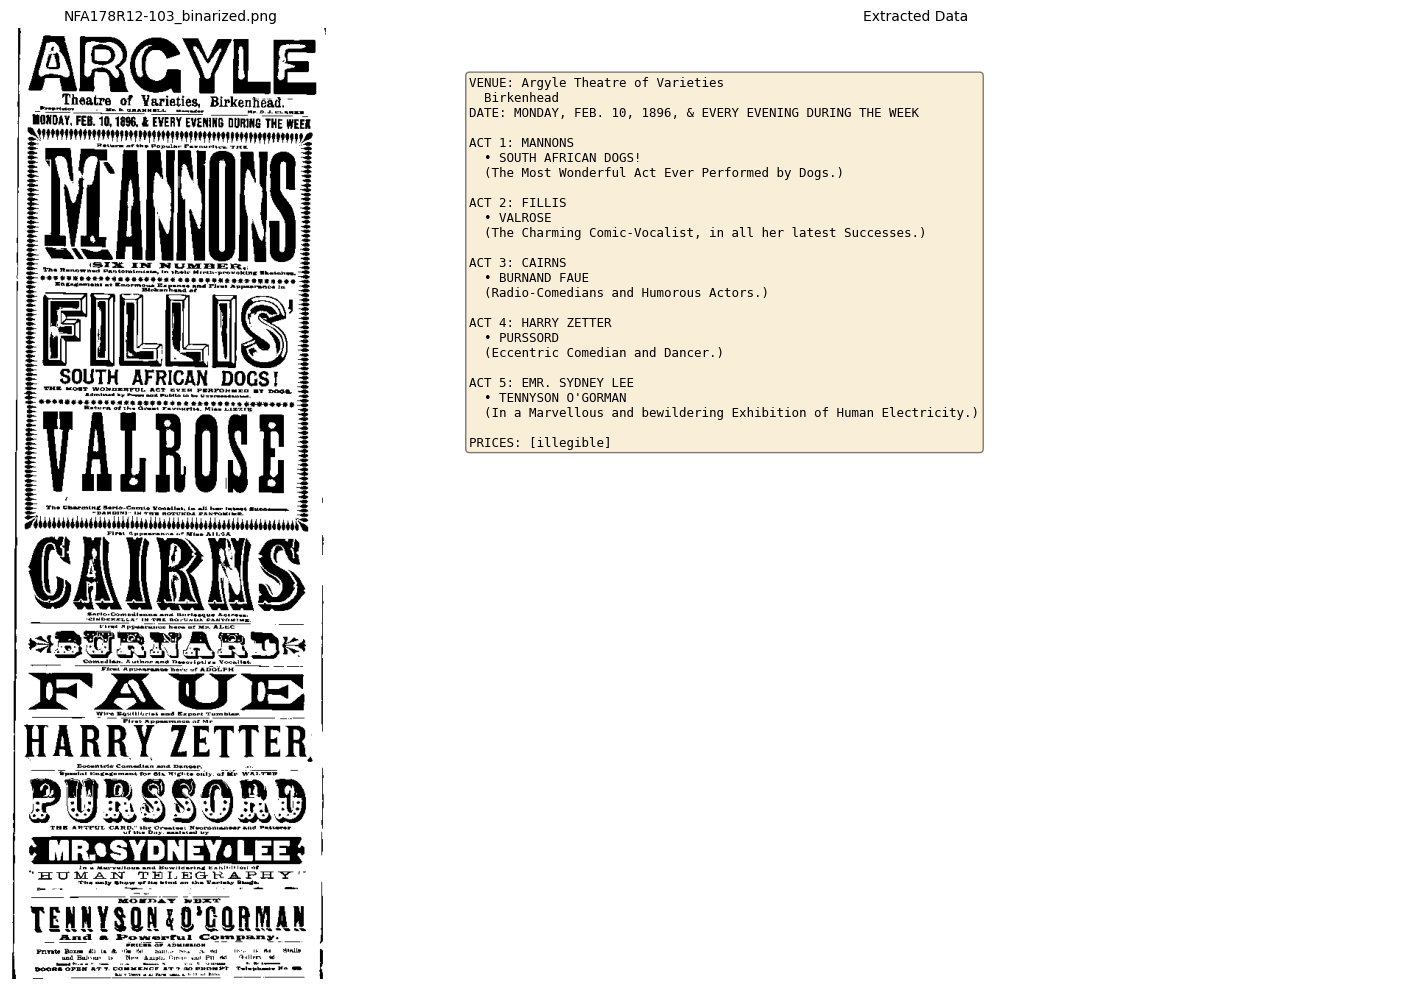

In [ ]:
# Show poster image with its extracted data
POSTER_INDEX = 0

if POSTER_INDEX < len(results):
    r = results[POSTER_INDEX]
    img_path = r.get("source_image", "")

    fig, (ax_img, ax_txt) = plt.subplots(1, 2, figsize=(16, 10),
                                          gridspec_kw={"width_ratios": [1, 1.5]})

    if os.path.exists(img_path):
        img = Image.open(img_path)
        ax_img.imshow(img, cmap="gray" if img.mode == "L" else None)
    ax_img.set_title(os.path.basename(img_path), fontsize=10)
    ax_img.axis("off")

    lines = []
    if "venue" in r:
        lines.append(f"VENUE: {r['venue'].get('name', '?')}")
        lines.append(f"  {r['venue'].get('location', '')}")
    if "date" in r:
        lines.append(f"DATE: {r['date']}")
    lines.append("")
    for j, act in enumerate(r.get("acts", []), 1):
        lines.append(f"ACT {j}: {act.get('act_name', '?')}")
        for p in act.get("performers", []):
            lines.append(f"  • {p}")
        if act.get("description"):
            lines.append(f"  ({act['description']})")
        lines.append("")
    if "ticket_prices" in r:
        lines.append(f"PRICES: {r['ticket_prices']}")

    ax_txt.text(0.05, 0.95, "\n".join(lines),
               transform=ax_txt.transAxes,
               verticalalignment="top",
               fontfamily="monospace", fontsize=9,
               bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))
    ax_txt.axis("off")
    ax_txt.set_title("Extracted Data", fontsize=10)

    plt.tight_layout()
    plt.show()

# Export to CSV

In [ ]:
import csv

CSV_PATH = "poster_acts.csv"

rows = []
for r in results:
    fname = os.path.basename(r.get("source_image", "unknown"))
    venue = r.get("venue", {})
    venue_name = venue.get("name", "") if isinstance(venue, dict) else str(venue)
    venue_loc = venue.get("location", "") if isinstance(venue, dict) else ""
    date = r.get("date", "")
    prices = r.get("ticket_prices", "")

    for act in r.get("acts", []):
        rows.append({
            "file": fname,
            "venue_name": venue_name,
            "venue_location": venue_loc,
            "date": date,
            "act_name": act.get("act_name", ""),
            "performers": "; ".join(act.get("performers", [])),
            "description": act.get("description", ""),
            "billing_notes": act.get("billing_notes", ""),
            "ticket_prices": prices,
        })

if rows:
    with open(CSV_PATH, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=rows[0].keys())
        writer.writeheader()
        writer.writerows(rows)

    print(f"CSV saved to: {CSV_PATH}")
    print(f"{len(rows)} act rows across {len(results)} posters")

    # Show first few rows
    print(f"\n{'File':<30} {'Act':<25} {'Performers':<30}")
    print("-" * 85)
    for row in rows[:15]:
        print(f"{row['file'][:28]:<30} {row['act_name'][:23]:<25} {row['performers'][:28]:<30}")
    if len(rows) > 15:
        print(f"  ... and {len(rows) - 15} more rows")
else:
    print("No acts found in results — nothing to export.")

CSV saved to: poster_acts.csv
144 act rows across 30 posters

File                           Act                       Performers                    
-------------------------------------------------------------------------------------
NFA178R12-103_binarized.png    MANNONS                   SOUTH AFRICAN DOGS!           
NFA178R12-103_binarized.png    FILLIS                    VALROSE                       
NFA178R12-103_binarized.png    CAIRNS                    BURNAND FAUE                  
NFA178R12-103_binarized.png    HARRY ZETTER              PURSSORD                      
NFA178R12-103_binarized.png    EMR. SYDNEY LEE           TENNYSON O'GORMAN             
NFA178R12-104_binarized.png    SPRY AND FLORENCE AUSTI   SPRY; AUSTIN                  
NFA178R12-104_binarized.png    MYRA MAY HOWARD           MYRA MAY HOWARD               
NFA178R12-104_binarized.png    BENNETT MARTELL           BENNETT MARTELL               
NFA178R12-104_binarized.png    KATE TOOLE                KAT